# 02d — Model Context Protocol (MCP)

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque2/02d-mcp.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> Este tema forma parte del **Bloque 2 — Orquestación**. Aquí se aprende
> a exponer datos y herramientas a LLMs de forma estandarizada con MCP.

In [1]:
!pip install -q fastmcp

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

## Model Context Protocol (MCP)

### El problema que resuelve

Conectar un LLM a múltiples fuentes de datos (SQLite, APIs REST, CSV,
Google Drive, un servicio meteorológico) requiere un adaptador por cada
combinación de fuente y framework. Con 5 fuentes y 5 frameworks
distintos, eso son 5 × 5 = 25 adaptadores. En la práctica, cada fuente
expone varios métodos, por lo que el número crece todavía más. Es el
problema $n \times m$.

Para resolverlo, Anthropic impulsó el Model Context Protocol (MCP), un
protocolo abierto que estandariza la conexión entre LLMs y fuentes
externas. Funciona como un “USB-C para LLMs”: una interfaz única para
todo. Con MCP, el número de adaptadores se reduce a $n + m$, ya que las
fuentes se conectan a través de un servidor MCP común y solo hace falta
un adaptador por modelo.

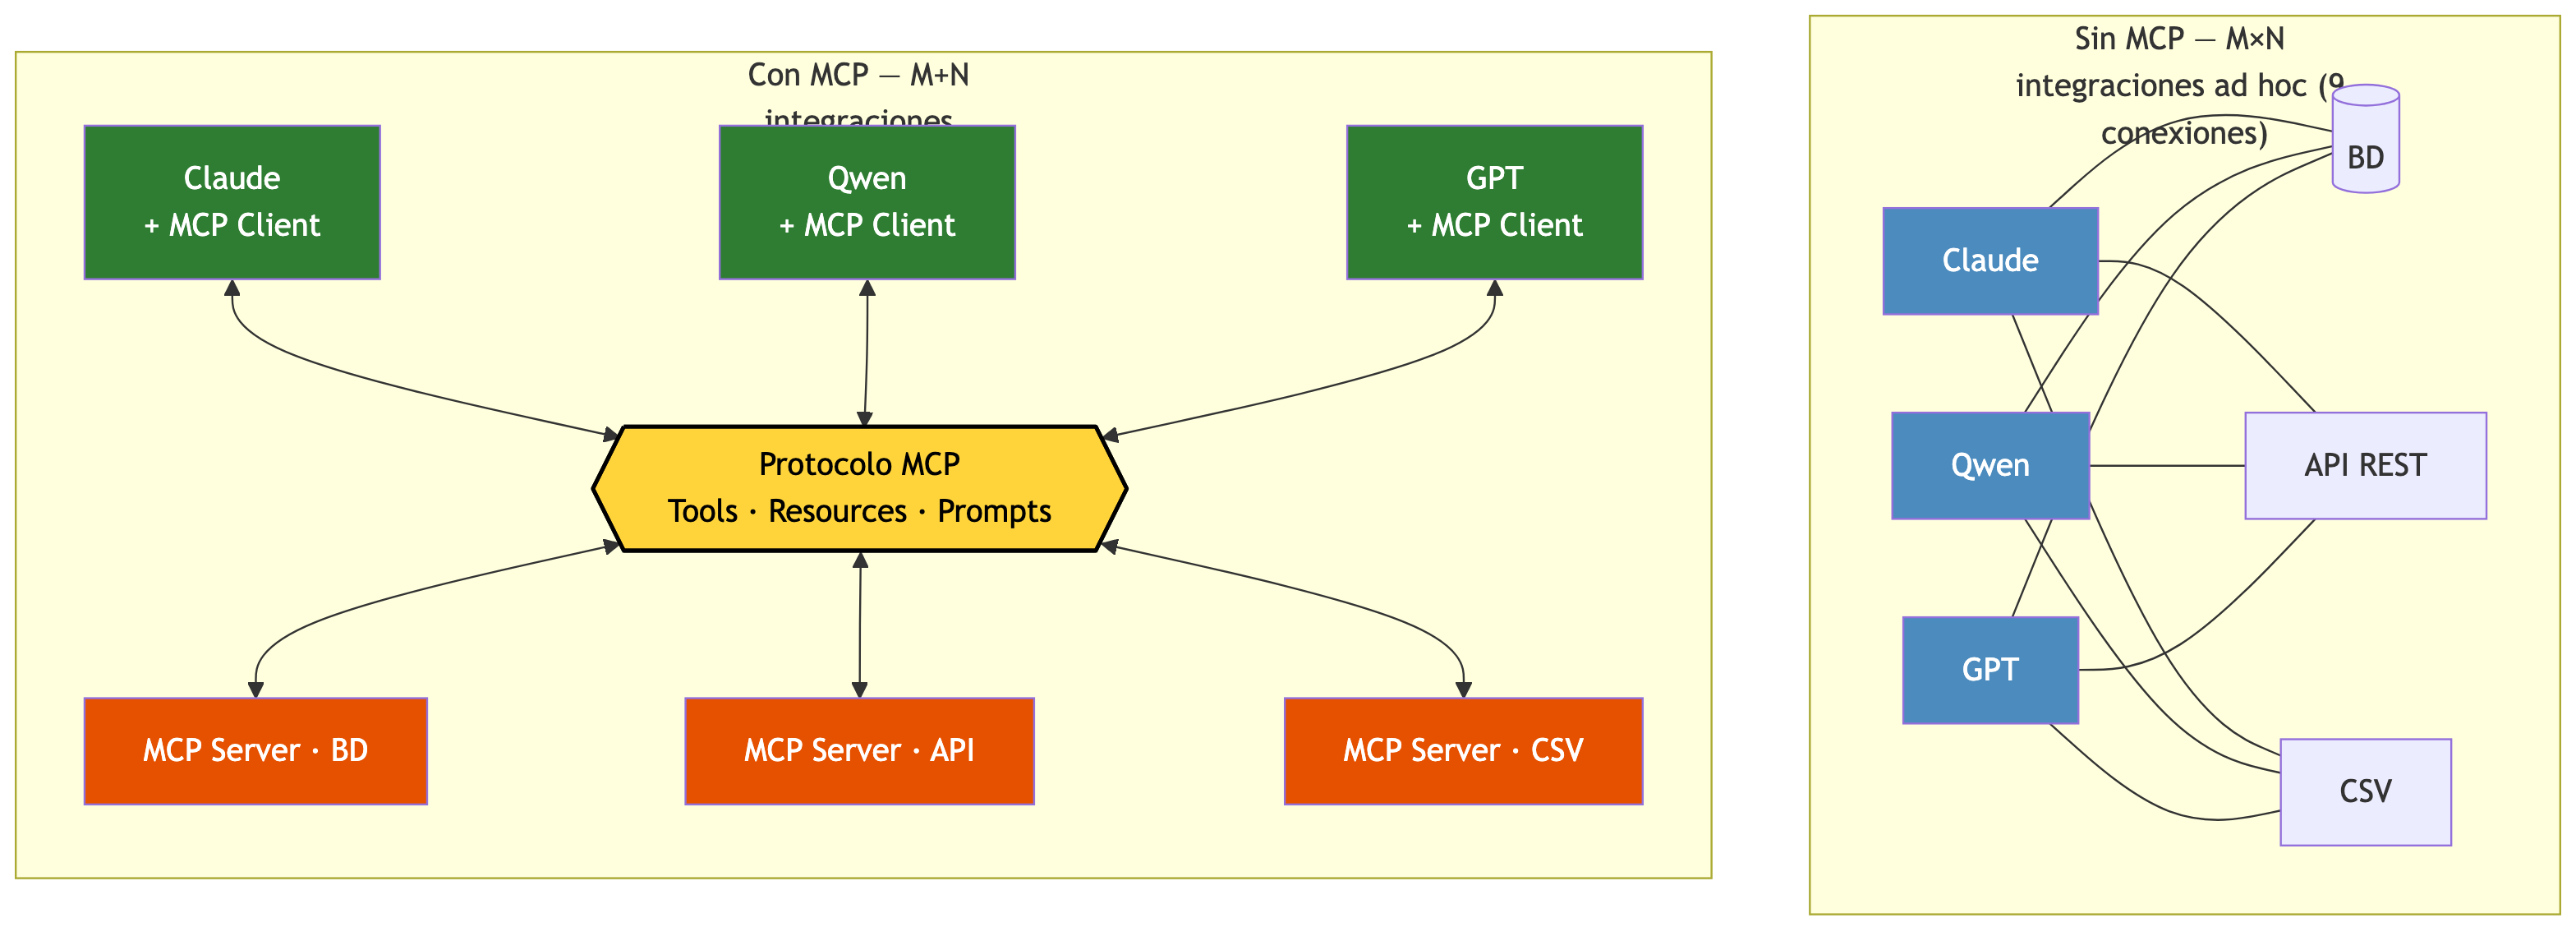

### Arquitectura de MCP

MCP sigue el modelo **cliente-servidor**. Cada servidor expone
capacidades en 3 categorías:

| Primitiva | ¿Qué es? | Ejemplo |
|------------------------|------------------------|------------------------|
| **Tools** | Funciones que el LLM puede invocar | `ejecutar_sql(query)`, `buscar_cliente(id)` |
| **Resources** | Datos expuestos como recursos de solo lectura | `schema://tablas`, `datos://ventas_2025` |
| **Prompts** | Plantillas de prompt predefinidas | `analisis_ventas(mes)`, `resumen_ejecutivo()` |

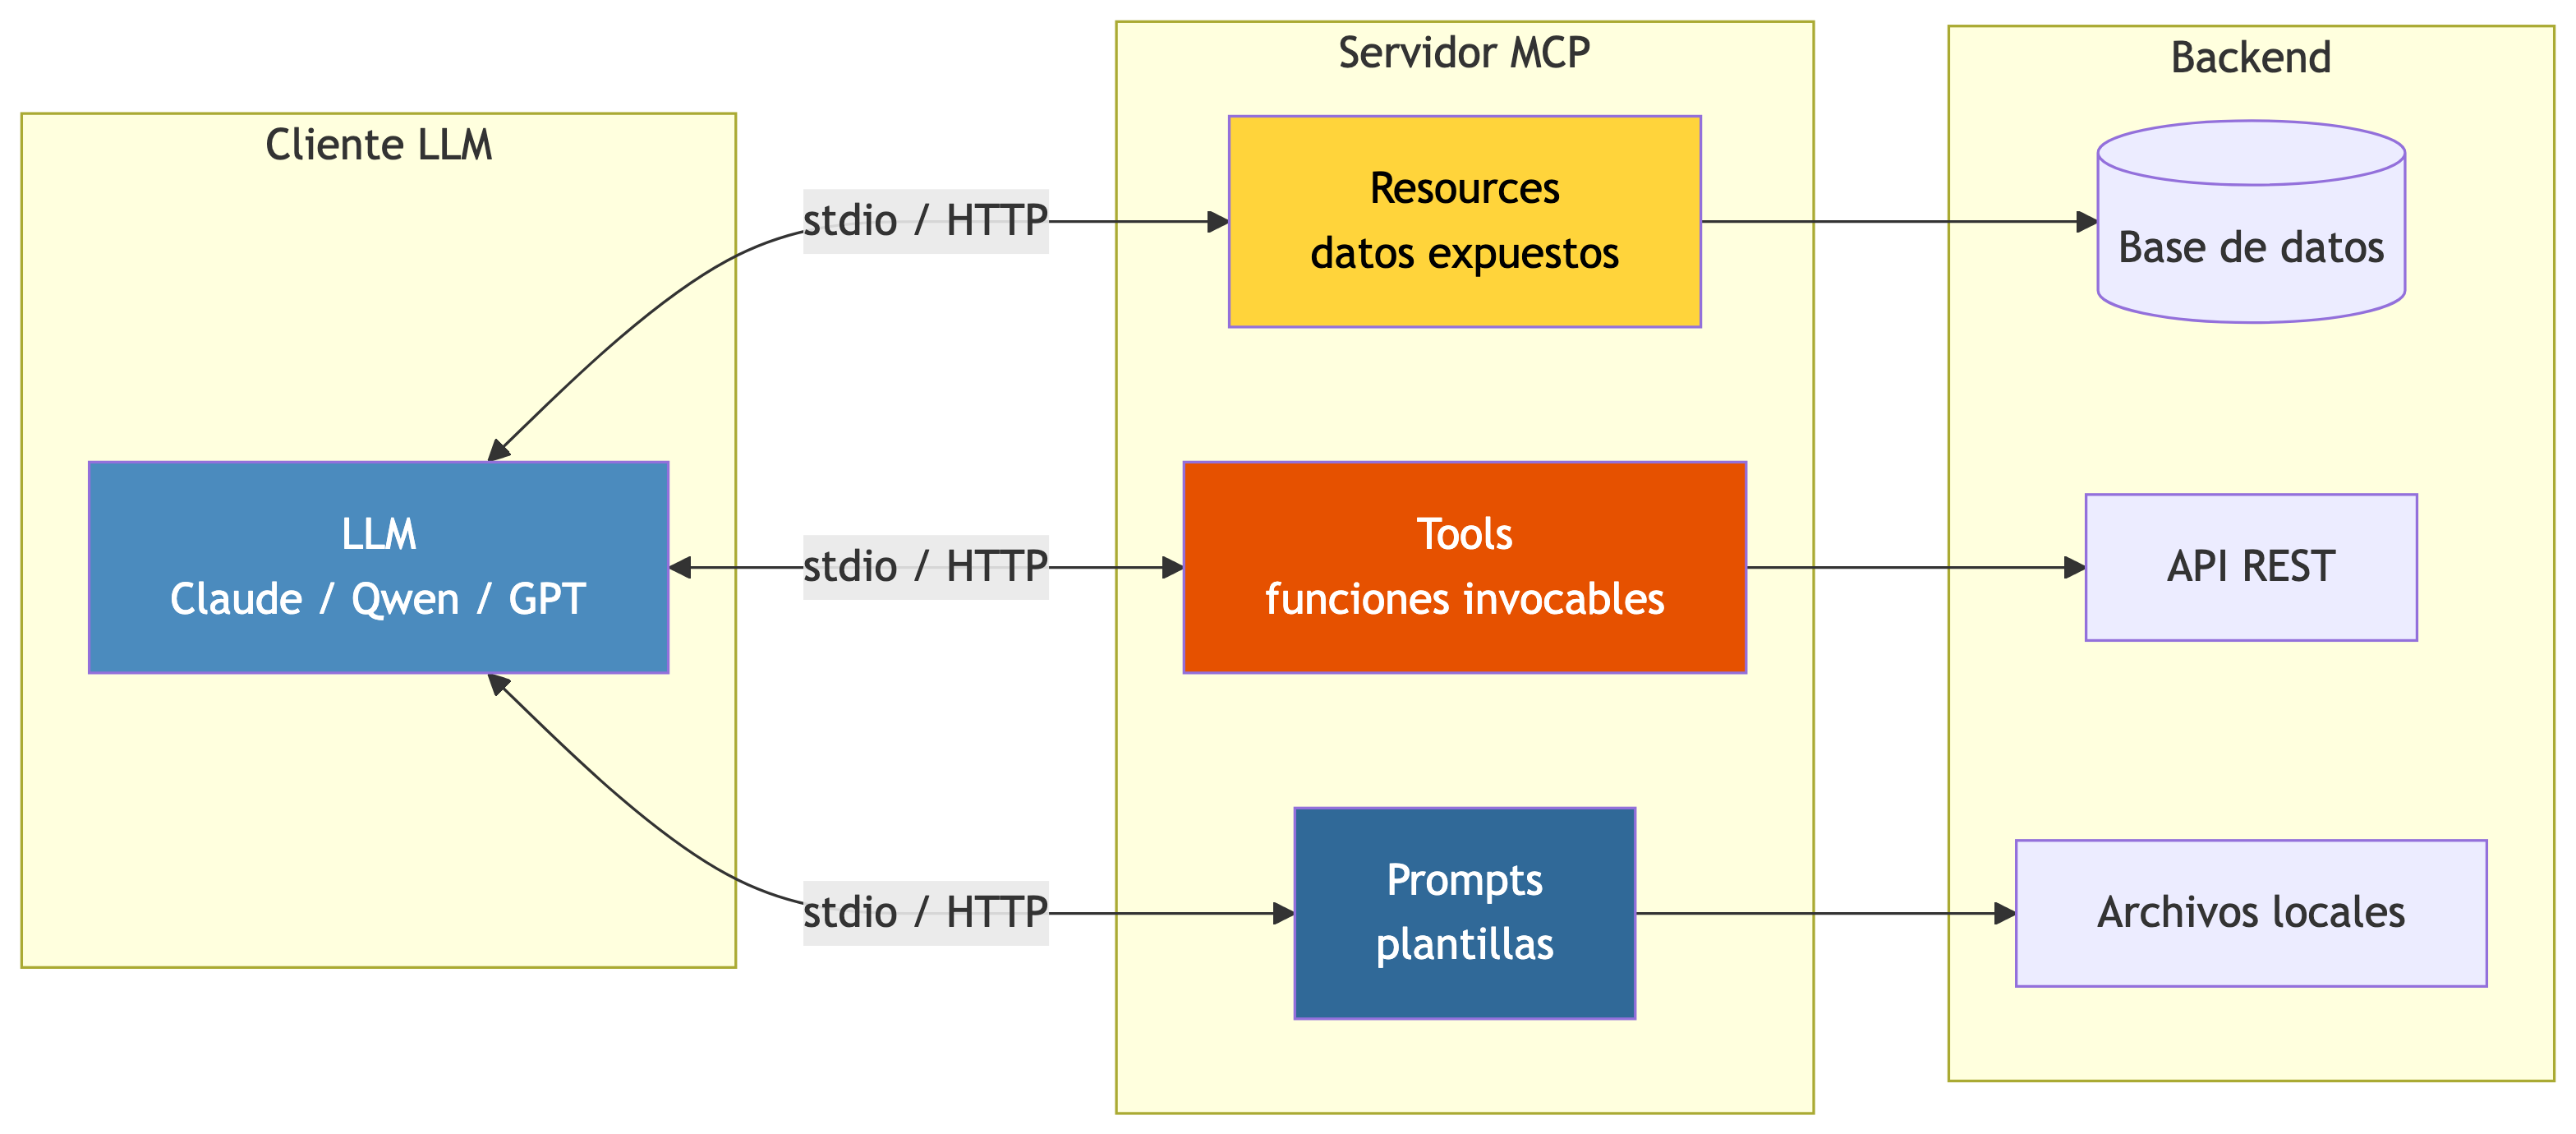

### Transporte: stdio vs HTTP

| Transporte | Cómo funciona | Cuándo usarlo |
|------------------------|------------------------|------------------------|
| **stdio** | El cliente lanza el servidor como subproceso, comunicación por stdin/stdout | Local, sin red, máxima seguridad |
| **HTTP (SSE)** | El servidor escucha en un puerto, el cliente se conecta por HTTP | Remoto, multi-cliente, cloud |

En este curso usamos **stdio** porque es el más simple y seguro para
entornos locales.

### FastMCP: el SDK simplificado

FastMCP es una capa por encima del SDK oficial que simplifica mucho
crear servidores. Basta con decorar funciones Python normales:

In [3]:
from fastmcp import FastMCP

mcp = FastMCP("Mi Primer Servidor")

@mcp.tool()
def sumar(a: float, b: float) -> float:
    """Suma dos números. Ejemplo: sumar(3, 5) → 8"""
    return a + b

@mcp.tool()
def multiplicar(a: float, b: float) -> float:
    """Multiplica dos números. Ejemplo: multiplicar(4, 7) → 28"""
    return a * b

@mcp.tool()
def contar_palabras(texto: str) -> int:
    """Cuenta el número de palabras en un texto."""
    return len(texto.split())

# Las herramientas son funciones Python normales: se pueden probar directamente
print("=== Probando herramientas directamente ===")
print(f"sumar(3, 5) = {sumar(3, 5)}")
print(f"multiplicar(4, 7) = {multiplicar(4, 7)}")
print(f"contar_palabras('Hola mundo MCP') = {contar_palabras('Hola mundo MCP')}")

=== Probando herramientas directamente ===
sumar(3, 5) = 8
multiplicar(4, 7) = 28
contar_palabras('Hola mundo MCP') = 3

> **Tip**
>
> FastMCP **infiere automáticamente el JSON Schema** a partir de los
> type hints de Python. `a: float` se convierte en `{"type": "number"}`,
> `texto: str` en `{"type": "string"}`, etc. No necesitas escribir el
> schema manualmente.

### Recursos MCP

Los **Resources** exponen datos de solo lectura que el LLM puede
consultar:

In [4]:
@mcp.resource("config://version")
def get_version() -> str:
    """Versión del servidor."""
    return "1.0.0"

@mcp.resource("stats://herramientas")
async def get_stats() -> str:
    """Estadísticas del servidor."""
    tools = await mcp.list_tools()
    return f"Tools registradas: {len(tools)}"

# Los recursos también son funciones normales
print(f"Versión del servidor: {get_version()}")
print(f"Estadísticas: {await get_stats()}")

Versión del servidor: 1.0.0
Estadísticas: Tools registradas: 3

### MCP + SQLite: herramienta de consulta

El caso de uso más común: permitir que un LLM consulte una base de datos
SQLite de forma segura:

In [5]:
import sqlite3

# Creamos una BD de ejemplo con datos corporativos
db = sqlite3.connect(":memory:")
db.execute("CREATE TABLE ventas (id INTEGER, fecha TEXT, producto TEXT, importe REAL, cliente_id INTEGER)")
db.execute("CREATE TABLE clientes (id INTEGER, nombre TEXT, sector TEXT, facturacion REAL)")
db.execute("INSERT INTO clientes VALUES (1, 'ACME Corp', 'Tecnología', 500000)")
db.execute("INSERT INTO clientes VALUES (2, 'IberTech SA', 'Industrial', 1200000)")
db.execute("INSERT INTO clientes VALUES (3, 'Datafy Analytics', 'Consultoría', 300000)")
db.execute("INSERT INTO ventas VALUES (1, '2025-01-15', 'CloudSync', 45000, 1)")
db.execute("INSERT INTO ventas VALUES (2, '2025-02-20', 'DataViz', 32000, 2)")
db.execute("INSERT INTO ventas VALUES (3, '2025-03-10', 'CloudSync', 51000, 1)")
db.execute("INSERT INTO ventas VALUES (4, '2025-04-05', 'AI Toolkit', 28000, 3)")
db.execute("INSERT INTO ventas VALUES (5, '2025-05-18', 'DataViz', 19000, 2)")
db.commit()

print("=== Base de datos corporativa ===")
for row in db.execute("SELECT v.id, v.fecha, v.producto, v.importe, c.nombre FROM ventas v JOIN clientes c ON v.cliente_id = c.id"):
    print(f"  Venta {row[0]}: {row[1]} | {row[2]:12s} | {row[3]:6.0f}€ | {row[4]}")

# NOTA: db sigue abierta en memoria; las tools la usarán directamente
# No necesita backup a disco porque las tools comparten el mismo kernel

=== Base de datos corporativa ===
  Venta 1: 2025-01-15 | CloudSync    |  45000€ | ACME Corp
  Venta 2: 2025-02-20 | DataViz      |  32000€ | IberTech SA
  Venta 3: 2025-03-10 | CloudSync    |  51000€ | ACME Corp
  Venta 4: 2025-04-05 | AI Toolkit   |  28000€ | Datafy Analytics
  Venta 5: 2025-05-18 | DataViz      |  19000€ | IberTech SA

In [6]:
# Herramienta MCP con validación de seguridad

def sanitizar_query(query: str) -> str:
    """Bloquea comandos peligrosos. Solo permite SELECT."""
    peligrosos = ["DROP", "DELETE", "UPDATE", "INSERT", "ALTER", "CREATE", "TRUNCATE"]
    query_upper = query.upper()
    for cmd in peligrosos:
        if cmd in query_upper:
            raise ValueError(f"Operación no permitida: {cmd}. Solo se admiten consultas SELECT.")
    if not query_upper.strip().startswith("SELECT"):
        raise ValueError("Solo se permiten consultas SELECT.")
    return query

@mcp.tool()
def consultar_sql(query: str) -> str:
    """
    Ejecuta una consulta SELECT en la base de datos corporativa.

    Schema disponible:
    - ventas(id, fecha, producto, importe, cliente_id)
    - clientes(id, nombre, sector, facturacion)

    Args:
        query: consulta SQL SELECT. Ejemplo: 'SELECT * FROM ventas WHERE importe > 30000'

    Returns:
        Resultados de la consulta en formato tabla.
    """
    try:
        query = sanitizar_query(query)
        cursor = db.execute(query)

        columnas = [d[0] for d in cursor.description]
        filas = cursor.fetchall()

        if not filas:
            return "La consulta no devolvió resultados."

        resultado = " | ".join(columnas) + "\n" + "-" * 40 + "\n"
        for fila in filas[:20]:
            resultado += " | ".join(str(v) for v in fila) + "\n"
        resultado += f"\nTotal filas: {len(filas)}"
        return resultado
    except Exception as e:
        return f"Error: {e}"

# Probar directamente (sin servidor MCP)
print("=== Probando herramienta SQL ===")
print(consultar_sql("SELECT * FROM ventas WHERE producto = 'CloudSync'"))
print()
print(consultar_sql("SELECT c.nombre, SUM(v.importe) as total_ventas FROM ventas v JOIN clientes c ON v.cliente_id = c.id GROUP BY c.nombre"))
print()
print("--- Test de seguridad ---")
print(consultar_sql("DROP TABLE ventas"))

=== Probando herramienta SQL ===
id | fecha | producto | importe | cliente_id
----------------------------------------
1 | 2025-01-15 | CloudSync | 45000.0 | 1
3 | 2025-03-10 | CloudSync | 51000.0 | 1

Total filas: 2

nombre | total_ventas
----------------------------------------
ACME Corp | 96000.0
Datafy Analytics | 28000.0
IberTech SA | 51000.0

Total filas: 3

--- Test de seguridad ---
Error: Operación no permitida: DROP. Solo se admiten consultas SELECT.

### Seguridad en MCP: el checklist imprescindible

Cada servidor MCP es una **superficie de ataque**. El LLM escribe el
input de las herramientas, y un atacante puede manipular el prompt para
inyectar comandos maliciosos (**prompt injection**):

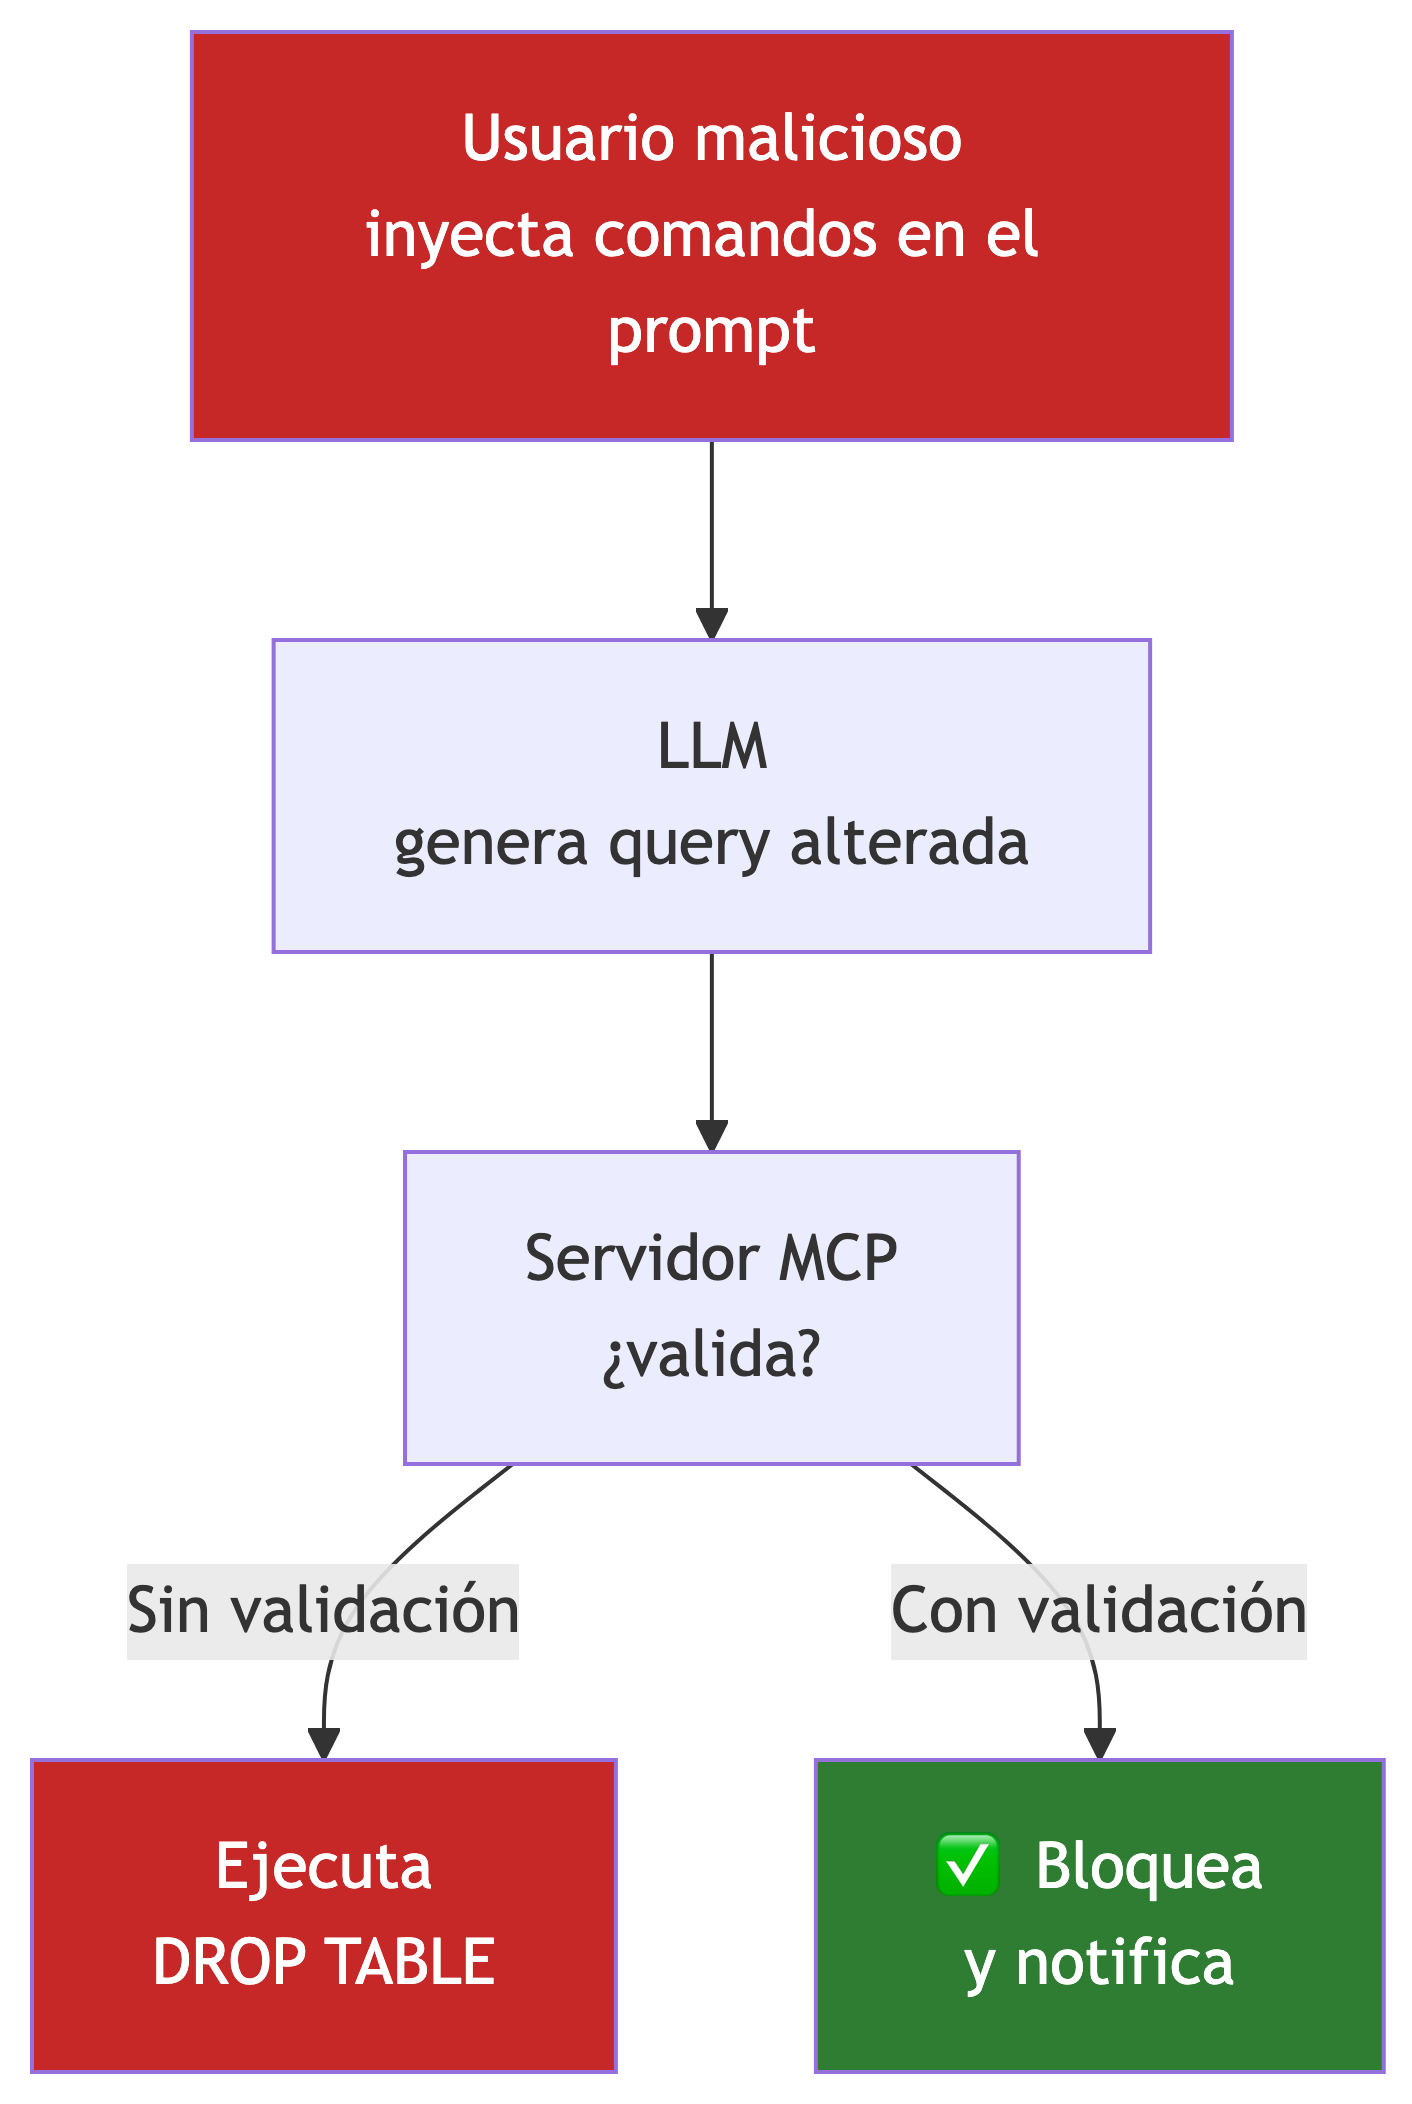

> **Checklist de seguridad MCP**
>
> | Riesgo | Mitigación |
> |------------------------------------|------------------------------------|
> | **SQL Injection vía prompt** | Solo permitir SELECT, sanitizar query |
> | **Data leakage** | Limitar filas devueltas (TOP 100), no exponer columnas sensibles |
> | **Path traversal** | Validar rutas con `os.path.abspath`, restringir a un directorio base |
> | **Denegación de servicio** | Timeout en queries (máx. 5s), límite de memoria |
> | **Acceso no autorizado** | Autenticación en el transporte (API keys), logs de auditoría |
> | **Escalada de privilegios** | Principio de mínimo privilegio: cada tool accede solo a lo que necesita |

### Servidor MCP completo para ejecutar como script

Guarda el siguiente código en `servidor_mcp.py` y ejecútalo con
`python servidor_mcp.py`. Los clientes LLM pueden conectarse vía stdio:

In [7]:
# servidor_mcp.py — Servidor listo para producción
# Para ejecutar: python servidor_mcp.py
# El servidor queda escuchando por stdio

from fastmcp import FastMCP
import sqlite3
import os

mcp = FastMCP("Servidor Corporativo")

DB_PATH = os.path.join(os.path.dirname(__file__), "datos", "corporativa.db")

def _sanitizar(query: str) -> str:
    prohibidos = ["DROP", "DELETE", "UPDATE", "INSERT", "ALTER", "CREATE", "TRUNCATE"]
    for cmd in prohibidos:
        if cmd in query.upper():
            raise ValueError(f"Operación bloqueada: {cmd}")
    if not query.upper().strip().startswith("SELECT"):
        raise ValueError("Solo SELECT permitido")
    return query

@mcp.tool()
def consultar_ventas(query: str) -> str:
    """
    Ejecuta una consulta SELECT en la BD corporativa.
    Tablas: ventas(id, fecha, producto, importe, cliente_id), clientes(id, nombre, sector)
    """
    try:
        query = _sanitizar(query)
        conn = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()
        cursor.execute(query)
        cols = [d[0] for d in cursor.description]
        rows = cursor.fetchall()
        conn.close()
        header = " | ".join(cols) + "\n" + "-" * 50 + "\n"
        body = "\n".join(" | ".join(str(v) for v in r) for r in rows[:100])
        return header + body + f"\n\n{len(rows)} filas."
    except Exception as e:
        return f"Error: {e}"

@mcp.resource("schema://tablas")
def esquema_bd() -> str:
    """Devuelve el esquema SQL de todas las tablas."""
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("SELECT sql FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'")
    schemas = [r[0] for r in cursor.fetchall() if r[0]]
    conn.close()
    return "\n\n".join(schemas) if schemas else "Sin tablas definidas."

if __name__ == "__main__":
    mcp.run()

### Conexión desde un cliente LLM

Un cliente (LLM o aplicación) se conecta al servidor MCP lanzándolo como
subproceso:

In [8]:
# cliente_mcp.py — Cómo conectar un LLM al servidor MCP
import asyncio
from fastmcp import Client

async def main():
    async with Client("python", "servidor_mcp.py") as client:
        # Listar herramientas disponibles
        tools = await client.list_tools()
        print("Herramientas disponibles:")
        for t in tools:
            print(f"  - {t.name}: {t.description}")

        # Ejecutar una consulta
        result = await client.call_tool(
            "consultar_ventas",
            {"query": "SELECT * FROM ventas WHERE importe > 30000"}
        )
        print(f"\nResultado:\n{result}")

asyncio.run(main())

### Resumen visual

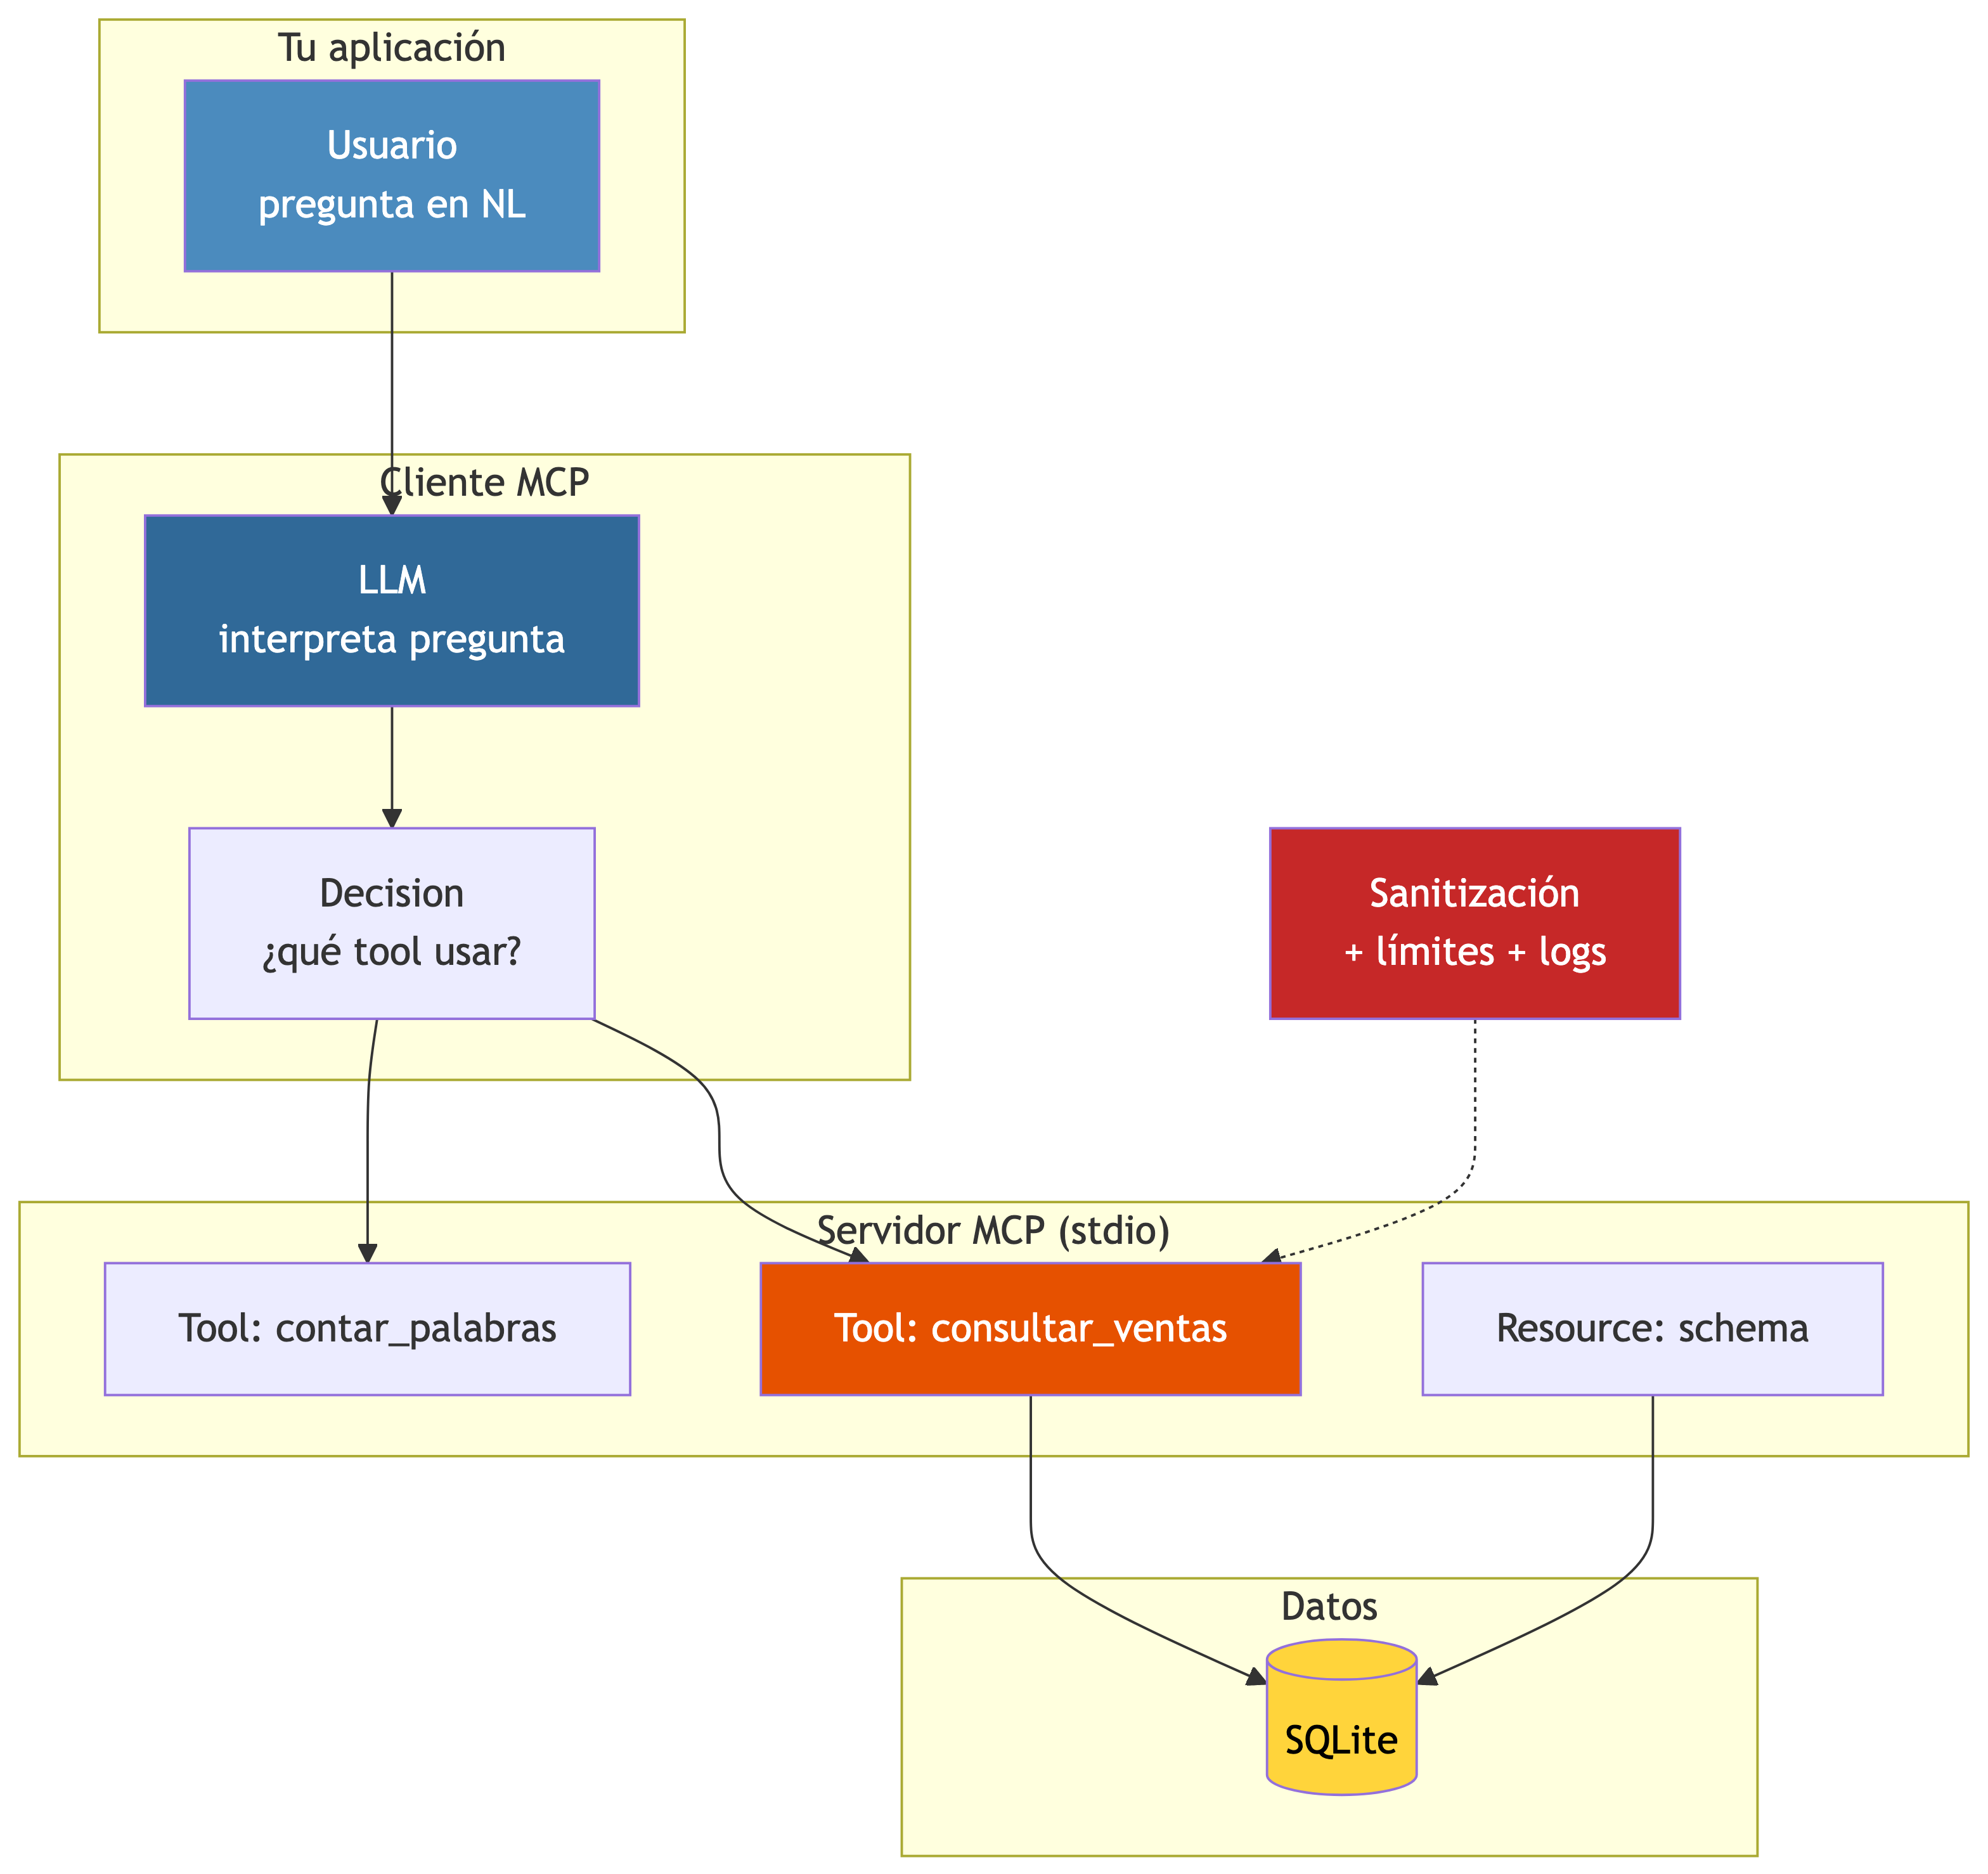

> **Lectura recomendada:** [Model Context Protocol
> Specification](https://spec.modelcontextprotocol.io/) \| [FastMCP
> Documentation](https://gofastmcp.com/)